In [3]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

n = np.arange(-2, 5)
x = np.array([0, 1, 1, 1, 1, 0.5, 0.5])

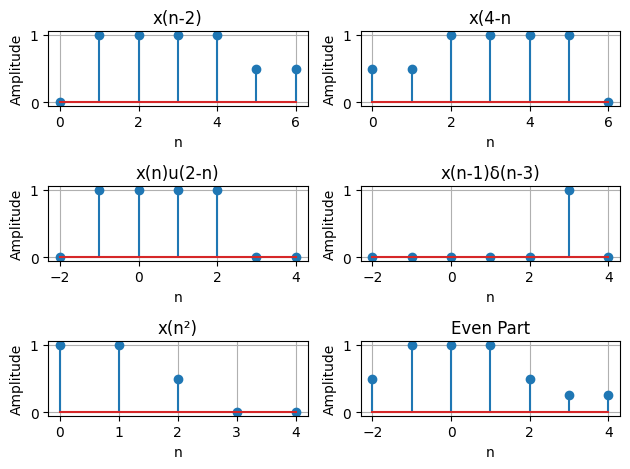

In [13]:
# (a) x(n-2)  -> delay

n1 = n + 2 # delay

plt.subplot(3,2,1)
plt.stem(n1, x)
plt.title("x(n-2)")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.grid(True, which="both")

plt.tight_layout()

# (b) x(4-n) -> delay

n2 = -n + 4

plt.subplot(3,2,2)
plt.stem(n2, x)
plt.title("x(4-n")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.grid(True, which="both")

plt.tight_layout()



# (c) x(n) u(2-n)

u = np.where(n <= 2, 1, 0)  # explanation below
y3 = x * u

plt.subplot(3,2,3)
plt.stem(n, y3)
plt.title("x(n)u(2-n)")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.grid()

plt.tight_layout()



# (d) x(n-1) d(n-3)

delta = np.where(n==3, 1, 0)
n4 = n + 1

amp = x[np.where(n4 == 3)][0]
y4 = amp * delta

plt.subplot(3,2,4)
plt.stem(n, y4)
plt.title("x(n-1)δ(n-3)")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.grid()
plt.tight_layout()



# (e) x(n^2)

n_sq = np.arange(0,5)

y5 = []

for i in n_sq:
    index = i*i
    if index in n:
        y5.append(x[np.where(n==index)][0])

    else:
        y5.append(0)

plt.subplot(3,2,5)
plt.stem(n_sq, y5)
plt.title("x(n²)")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.grid()
plt.tight_layout()



# (f) even part of x(n)

x_even = []

for i in n:
    if -i in n:
        x_neg = x[np.where(n==-i)][0]

    else:
        x_neg = 0

    x_pos = x[np.where(n==i)][0]
    x_even.append((x_pos+x_neg)/2)


plt.subplot(3,2,6)
plt.stem(n, x_even)
plt.title("Even Part")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.grid()

plt.tight_layout()

## Z-transform of x(n) u(n+3)  --> Explanation below

In [16]:
z = sp.Symbol('z')

X = (z + 1 + z**(-1) + z**(-2) + (1/2) * z**(-3) + (1/2) * z**(-4))
sp.pprint(X)

        1   1    0.5   0.5
z + 1 + ─ + ── + ─── + ───
        z    2    3     4 
            z    z     z  


## (c) What is $u(2-n)$?

Normally, the **unit step function** is defined as

$$
u(n)=
\begin{cases}
1, & n \ge 0 \\
0, & n < 0
\end{cases}
$$

Now replace **\(n\)** with **\(2-n\)**.

Therefore,

$$
u(2-n)=
\begin{cases}
1, & 2-n \ge 0 \\
0, & 2-n < 0
\end{cases}
$$

Now solve the inequality.

$$
2-n \ge 0
$$

Move 2 to the other side:

$$
-n \ge -2
$$

Multiply both sides by **\(-1\)**.

> **Note:** Whenever an inequality is multiplied or divided by a **negative number**, the inequality sign **reverses**.

Therefore,

$$
n \le 2
$$

Hence, the unit step function becomes

$$
u(2-n)=
\begin{cases}
1, & n \le 2 \\
0, & n > 2
\end{cases}
$$


## (d) Logic Behind Using `amp`

The expression is

$$
x(n-1)\delta(n-3)
$$

The impulse function

$$
\delta(n-3)
$$

is **zero everywhere except at \(n=3\)**.

Therefore, we only need the value of the delayed signal at \(n=3\).

Substitute \(n=3\):

$$
x(3-1)=x(2)
$$

From the given signal,

$$
x(2)=1
$$

So the output is

$$
1\cdot\delta(n-3)
$$

In Python, we store this value in `amp`:

```python
amp = x[np.where(n_shift == 3)][0]
```

Using `amp` makes the code **general**. If the value of \(x(2)\) changes in another question, the code still works automatically without changing any numbers.

## (e) Logic Behind `x(n^2)`

The expression is

$$
x(n^2)
$$

Instead of using the original index \(n\), we first compute \(n^2\). The squared value is then used as the new index to access the original signal.

For example,

| \(n\) | \(n^2\) |
|:-----:|:--------:|
| 0 | 0 |
| 1 | 1 |
| 2 | 4 |
| 3 | 9 |

Now we look for the values of

$$
x(0),\;x(1),\;x(4),\;x(9)
$$

If an index exists in the original signal, we take its corresponding amplitude. Otherwise, we assign **0**.

---

## Python Code

```python
n_sq = np.arange(0, 5)

y5 = []

for i in n_sq:
    index = i * i

    if index in n:
        y5.append(x[np.where(n == index)][0])
    else:
        y5.append(0)
```

---

## Explanation of the Code

### Step 1: Create the New Indices

```python
n_sq = np.arange(0, 5)
```

Creates the indices

```text
[0, 1, 2, 3, 4]
```

These are the values of \(n\) for which we will calculate \(x(n^2)\).

---

### Step 2: Create an Empty List

```python
y5 = []
```

An empty list is created to store the output signal.

---

### Step 3: Loop Through Every Value of \(n\)

```python
for i in n_sq:
```

The loop processes one value of \(n\) at a time.

The iterations are:

| Iteration | `i` |
|:---------:|:---:|
| 1 | 0 |
| 2 | 1 |
| 3 | 2 |
| 4 | 3 |
| 5 | 4 |

---

### Step 4: Compute \(n^2\)

```python
index = i * i
```

For each iteration, the square of the current index is calculated.

| `i` | `index = i*i` |
|:---:|:-------------:|
| 0 | 0 |
| 1 | 1 |
| 2 | 4 |
| 3 | 9 |
| 4 | 16 |

These values are the indices used to access the original signal.

---

### Step 5: Check Whether the Index Exists

```python
if index in n:
```

Some squared indices (such as **9** and **16**) are not present in the original signal.

- If the index exists, retrieve its amplitude.
- Otherwise, use **0**.

This prevents index errors.

---

### Step 6: Retrieve the Amplitude

```python
x[np.where(n == index)][0]
```

This line searches for the position where the index equals `index` and retrieves the corresponding amplitude.

For example,

- `index = 4` → retrieves `x(4) = 0.5`
- `index = 9` → does not exist, so `0` is stored.

---

### Step 7: Store the Result

```python
y5.append(...)
```

The computed amplitude is added to the output list.

After all iterations,

```text
y5 = [x(0), x(1), x(4), 0, 0]
```

because the indices **9** and **16** do not exist in the original signal.

---

## Final Logic

The program:

1. Generates the values of \(n\).
2. Computes \(n^2\).
3. Checks whether \(n^2\) exists in the original signal.
4. Retrieves the corresponding amplitude if it exists.
5. Stores **0** if it does not exist.
6. Repeats the process until all values of \(n\) have been processed.

## (f) Logic Behind Finding the Even Part of a Signal

The even part of a signal is given by

$$
x_e[n]=\frac{x[n]+x[-n]}{2}
$$

To calculate the even part:

1. Take the original signal \(x[n]\).
2. Find its reflected version \(x[-n]\).
3. Add both signals together.
4. Divide the result by **2**.

---

## Python Code

```python
x_even = []

for i in n:

    if -i in n:
        x_neg = x[np.where(n == -i)][0]
    else:
        x_neg = 0

    x_pos = x[np.where(n == i)][0]

    x_even.append((x_pos + x_neg) / 2)
```

---

## Explanation of the Code

### Step 1: Create an Empty List

```python
x_even = []
```

This list will store the even part of the signal.

---

### Step 2: Traverse Every Sample

```python
for i in n:
```

The loop processes each index of the signal one by one.

---

### Step 3: Find the Reflected Sample

```python
if -i in n:
    x_neg = x[np.where(n == -i)][0]
else:
    x_neg = 0
```

For every index \(i\), the program looks for its reflected index \(-i\).

- If it exists, its amplitude is stored in `x_neg`.
- If it does not exist, `0` is used.

For example,

- If \(i=2\), it searches for \(x(-2)\).
- If \(i=-1\), it searches for \(x(1)\).

---

### Step 4: Get the Original Sample

```python
x_pos = x[np.where(n == i)][0]
```

This retrieves the amplitude of the original signal at index \(i\).

---

### Step 5: Compute the Even Part

```python
x_even.append((x_pos + x_neg) / 2)
```

The even part is calculated using

$$
x_e[n]=\frac{x[n]+x[-n]}{2}
$$

The computed value is then stored in the `x_even` list.

---

## Final Logic

The program:

1. Visits each sample of the signal.
2. Finds the corresponding reflected sample.
3. Retrieves the original sample.
4. Computes

$$
\frac{x[n]+x[-n]}{2}
$$

5. Stores the result in the output list.

After all iterations, `x_even` contains the **even component** of the original signal.

# Logic Behind the Z-Transform of $x(n)u(n+3)$

We are given

$$
x(n)u(n+3)
$$

---

## Step 1: Understand the Unit Step Function

The unit step function is

$$
u(n+3)=
\begin{cases}
1, & n\ge-3\\
0, & n<-3
\end{cases}
$$

This means:

- All samples with \(n\ge-3\) are kept.
- All samples with \(n<-3\) become zero.

---

## Step 2: Check the Given Signal

The original signal exists only for

| n | -2 | -1 | 0 | 1 | 2 | 3 | 4 |
|---|---:|---:|---:|---:|---:|---:|---:|
| x[n] | 0 | 1 | 1 | 1 | 1 | 0.5 | 0.5 |

Notice that the smallest index is

$$
n=-2
$$

Since

$$
-2\ge-3
$$

every sample already satisfies the condition of the unit-step function.

Therefore,

$$
u(n+3)=1
$$

for every sample of the signal.

Hence,

$$
x(n)u(n+3)=x(n)
$$

The unit-step function does **not** change the signal.

---

# Step 3: Apply the Z-Transform

The general formula is

$$
X(z)=\sum_{n=-\infty}^{\infty}x[n]z^{-n}
$$

Since the signal is finite, the summation becomes

$$
X(z)=\sum_{n=-2}^{4}x[n]z^{-n}
$$

---

# Step 4: Substitute the Signal Values

From the given signal,

| n | x[n] |
|---|------|
| -2 | 0 |
| -1 | 1 |
| 0 | 1 |
| 1 | 1 |
| 2 | 1 |
| 3 | 0.5 |
| 4 | 0.5 |

Substitute each value into the summation:

$$
\begin{aligned}
X(z)
&=0\cdot z^2
+1\cdot z
+1
+z^{-1}
+z^{-2}
+0.5z^{-3}
+0.5z^{-4}
\end{aligned}
$$

Removing the zero term,

$$
X(z)=
z+1+z^{-1}+z^{-2}
+0.5z^{-3}
+0.5z^{-4}
$$

This is the final Z-Transform.

---

# Python Code

```python
import sympy as sp

z = sp.Symbol('z')

X = (
    z
    + 1
    + z**(-1)
    + z**(-2)
    + 0.5 * z**(-3)
    + 0.5 * z**(-4)
)

sp.pprint(X)
```

---

# Logic Behind the Code

- Since \(u(n+3)=1\) for all samples, we only need the original signal.
- Each sample is multiplied by \(z^{-n}\) according to the Z-transform definition.
- The resulting terms are added together to obtain \(X(z)\).
- `0.5` represents the amplitudes of the samples at \(n=3\) and \(n=4\).
- `sp.pprint()` displays the expression in a readable mathematical form.